In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.optimize import minimize

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_influenza_dataset.csv to master_influenza_dataset.csv


In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

print(df.shape)
df.head()
df.tail()

(780, 10)


,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
775,2025,35,8643,409159,2.07792,Region 9,2024_25,2025-08-25,51727260.0,16.708791
776,2025,36,8286,371227,2.21147,Region 9,2024_25,2025-09-01,51727260.0,16.018633
777,2025,37,8530,408760,2.08559,Region 9,2024_25,2025-09-08,51727260.0,16.490338
778,2025,38,8226,409936,2.00848,Region 9,2024_25,2025-09-15,51727260.0,15.902640
779,2025,39,8193,409146,2.02152,Region 9,2024_25,2025-09-22,51727260.0,15.838844


In [ ]:
print(df.columns)

Index(['Year', 'Week', 'ILI_Total', 'Total_Patients', 'Weighted_ILI', 'Region',
       'Season', 'Date', 'Population_2024', 'ILI_per_100k'],
      dtype='object')


In [ ]:
region_name = "Region 4"
season_name = "2023_24"

df_sub = df[
    (df["Region"] == region_name) &
    (df["Season"] == season_name)
].copy()

print(df_sub.shape)

(52, 10)


In [ ]:
df_sub["Season_Order"] = np.where(
    df_sub["Week"] >= 40,
    df_sub["Week"] - 40,
    df_sub["Week"] + 13
)

df_sub = df_sub.sort_values("Season_Order").reset_index(drop=True)

df_sub[["Week", "Season_Order"]].head()

,Week,Season_Order
0,40,0
1,41,1
2,42,2
3,43,3
4,44,4


In [ ]:
target_col = "ILI_per_100k"

df_sub["ILI_Smoothed"] = (
    df_sub[target_col]
    .rolling(window=3, center=True)
    .mean()
)

df_sub["ILI_Smoothed"] = df_sub["ILI_Smoothed"].fillna(df_sub[target_col])

observed = df_sub["ILI_Smoothed"].values
weeks = np.arange(len(observed))

# since target is per 100k
N = 100000

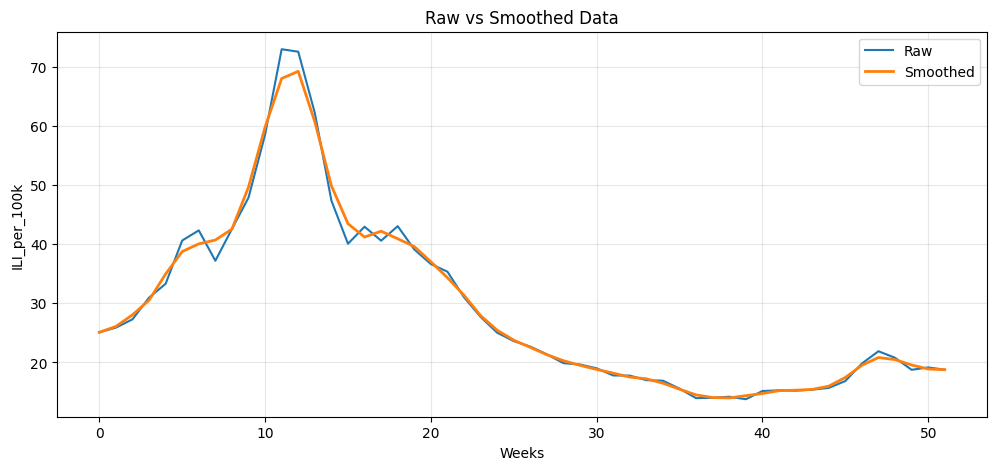

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df_sub[target_col].values, label="Raw")
plt.plot(observed, label="Smoothed", linewidth=2)

plt.title("Raw vs Smoothed Data")
plt.xlabel("Weeks")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def sir_model(y, t, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

In [ ]:
def simulate_sir(params, observed, N):

    beta, gamma, I0_frac, rho = params

    I0 = I0_frac * N
    R0 = 0
    S0 = N - I0

    y0 = [S0, I0, R0]

    t = np.arange(len(observed))

    sol = odeint(
        sir_model,
        y0,
        t,
        args=(beta, gamma, N)
    )

    S, I, R = sol.T

    predicted_obs = rho * I

    return predicted_obs, I

In [ ]:
def objective(params, observed, N):

    predicted_obs, _ = simulate_sir(params, observed, N)

    mse = np.mean((observed - predicted_obs) ** 2)

    return mse

In [ ]:
initial_guess = [
    0.8,        # beta
    0.3,        # gamma
    0.0005,     # I0_frac
    0.01        # rho
]

bounds = [
    (0.01, 3.0),
    (0.05, 1.5),
    (1e-7, 0.01),
    (1e-6, 1.0)
]

result = minimize(
    objective,
    initial_guess,
    args=(observed, N),
    method="L-BFGS-B",
    bounds=bounds
)

best_params = result.x
best_params

array([0.63383154, 0.56783972, 0.01      , 0.03210077])

In [ ]:
beta, gamma, I0_frac, rho = best_params

R0_est = beta / gamma

fitted_obs, infected_curve = simulate_sir(best_params, observed, N)

rmse = np.sqrt(np.mean((observed - fitted_obs) ** 2))
mae = np.mean(np.abs(observed - fitted_obs))

peak_obs = np.argmax(observed)
peak_fit = np.argmax(fitted_obs)

print("================================")
print("Improved SIR Results")
print("================================")
print("Region :", region_name)
print("Season :", season_name)
print("--------------------------------")
print("beta      :", round(beta,4))
print("gamma     :", round(gamma,4))
print("I0_frac   :", round(I0_frac,6))
print("rho       :", round(rho,6))
print("R0        :", round(R0_est,4))
print("--------------------------------")
print("RMSE      :", round(rmse,4))
print("MAE       :", round(mae,4))
print("Peak Error:", abs(peak_obs - peak_fit), "weeks")
print("================================")

Improved SIR Results
Region : Region 4
Season : 2023_24
--------------------------------
beta      : 0.6338
gamma     : 0.5678
I0_frac   : 0.01
rho       : 0.032101
R0        : 1.1162
--------------------------------
RMSE      : 8.4862
MAE       : 6.665
Peak Error: 0 weeks


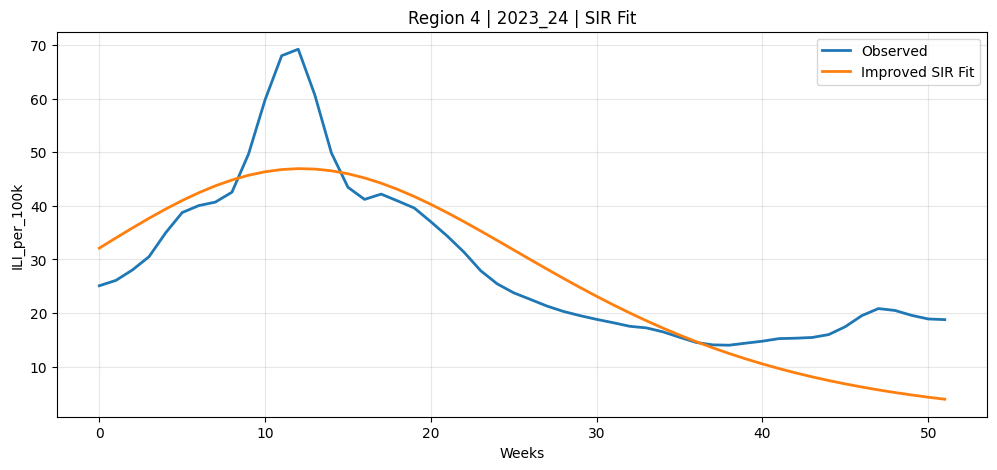

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    observed,
    label="Observed",
    linewidth=2
)

plt.plot(
    fitted_obs,
    label="Improved SIR Fit",
    linewidth=2
)

plt.title(f"{region_name} | {season_name} | SIR Fit")
plt.xlabel("Weeks")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

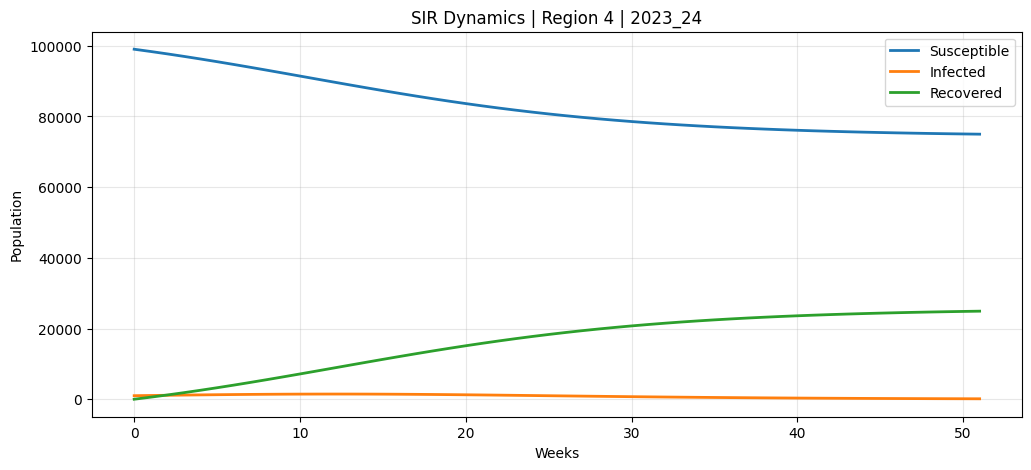

In [ ]:
# ==========================================
# INTERNAL SIR DYNAMICS PLOT
# ==========================================

beta, gamma, I0_frac, rho = best_params

I0 = I0_frac * N
R0 = 0
S0 = N - I0

y0 = [S0, I0, R0]

t = np.arange(len(observed))

sol = odeint(
    sir_model,
    y0,
    t,
    args=(beta, gamma, N)
)

S, I, R = sol.T

plt.figure(figsize=(12,5))

plt.plot(t, S, label="Susceptible", linewidth=2)
plt.plot(t, I, label="Infected", linewidth=2)
plt.plot(t, R, label="Recovered", linewidth=2)

plt.title(f"SIR Dynamics | {region_name} | {season_name}")
plt.xlabel("Weeks")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
selected_seasons = ["2023_24", "2024_25"]

regions = sorted(df["Region"].unique())

results = []
all_predictions = []

In [ ]:
for region_name in regions:

    for season_name in selected_seasons:

        df_sub = df[
            (df["Region"] == region_name) &
            (df["Season"] == season_name)
        ].copy()

        if len(df_sub) < 10:
            continue

        # -----------------------------------
        # Seasonal ordering
        # -----------------------------------
        df_sub["Season_Order"] = np.where(
            df_sub["Week"] >= 40,
            df_sub["Week"] - 40,
            df_sub["Week"] + 13
        )

        df_sub = df_sub.sort_values("Season_Order").reset_index(drop=True)

        # -----------------------------------
        # Target variable
        # -----------------------------------
        target_col = "ILI_per_100k"

        df_sub["ILI_Smoothed"] = (
            df_sub[target_col]
            .rolling(3, center=True)
            .mean()
        )

        df_sub["ILI_Smoothed"] = df_sub["ILI_Smoothed"].fillna(df_sub[target_col])

        observed = df_sub["ILI_Smoothed"].values

        N = 100000

        # -----------------------------------
        # Fit model
        # -----------------------------------
        initial_guess = [0.8, 0.3, 0.0005, 0.01]

        bounds = [
            (0.01, 3.0),
            (0.05, 1.5),
            (1e-7, 0.01),
            (1e-6, 1.0)
        ]

        try:
            result = minimize(
                objective,
                initial_guess,
                args=(observed, N),
                method="L-BFGS-B",
                bounds=bounds
            )

            best_params = result.x

            beta, gamma, I0_frac, rho = best_params

            fitted_obs, infected_curve = simulate_sir(
                best_params, observed, N
            )

            rmse = np.sqrt(np.mean((observed - fitted_obs)**2))
            mae = np.mean(np.abs(observed - fitted_obs))

            peak_obs = np.argmax(observed)
            peak_fit = np.argmax(fitted_obs)
            peak_error = abs(peak_obs - peak_fit)

            R0_est = beta / gamma

            # Save summary
            results.append({
                "Region": region_name,
                "Season": season_name,
                "beta": beta,
                "gamma": gamma,
                "R0": R0_est,
                "RMSE": rmse,
                "MAE": mae,
                "Peak_Error": peak_error
            })

            # Save fitted series
            for i in range(len(observed)):
                all_predictions.append({
                    "Region": region_name,
                    "Season": season_name,
                    "Week_Index": i,
                    "Observed": observed[i],
                    "Fitted": fitted_obs[i]
                })

        except:
            continue

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["Season", "RMSE"]
).reset_index(drop=True)

results_df.round(4)

,Region,Season,beta,gamma,R0,RMSE,MAE,Peak_Error
0,Region 6,2023_24,1.4534,1.3406,1.0842,3.2760,2.6264,2
1,Region 9,2023_24,0.5005,0.4550,1.1000,5.5313,4.1364,3
2,Region 4,2023_24,0.6338,0.5678,1.1162,8.4862,6.6650,0
3,Region 6,2024_25,0.7766,0.5666,1.3707,2.5451,2.1180,2
4,Region 9,2024_25,0.6511,0.5289,1.2311,6.8737,5.9143,3
5,Region 4,2024_25,0.6818,0.4963,1.3739,8.4749,6.9993,1


In [ ]:
results_df.groupby("Season")[["RMSE", "MAE", "Peak_Error"]].mean().round(3)

,RMSE,MAE,Peak_Error
Season,,,
2023_24,5.765,4.476,1.667
2024_25,5.965,5.011,2.000


In [ ]:
results_df.sort_values("RMSE").head(10).round(4)

,Region,Season,beta,gamma,R0,RMSE,MAE,Peak_Error
3,Region 6,2024_25,0.7766,0.5666,1.3707,2.5451,2.1180,2
0,Region 6,2023_24,1.4534,1.3406,1.0842,3.2760,2.6264,2
1,Region 9,2023_24,0.5005,0.4550,1.1000,5.5313,4.1364,3
4,Region 9,2024_25,0.6511,0.5289,1.2311,6.8737,5.9143,3
5,Region 4,2024_25,0.6818,0.4963,1.3739,8.4749,6.9993,1
2,Region 4,2023_24,0.6338,0.5678,1.1162,8.4862,6.6650,0


In [ ]:
# ==========================================================
# FUNCTION: Plot Observed vs Fitted SIR
# ==========================================================

def plot_sir_fit(pred_df, region_name, season_name):

    sample = pred_df[
        (pred_df["Region"] == region_name) &
        (pred_df["Season"] == season_name)
    ].copy()

    if sample.empty:
        print("No data found for selected Region / Season")
        return

    plt.figure(figsize=(12,5))

    plt.plot(
        sample["Observed"].values,
        label="Observed",
        linewidth=2
    )

    plt.plot(
        sample["Fitted"].values,
        label="SIR Fit",
        linewidth=2
    )

    plt.title(f"{region_name} | {season_name} | Observed vs Fitted SIR")
    plt.xlabel("Weeks")
    plt.ylabel("ILI_per_100k")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

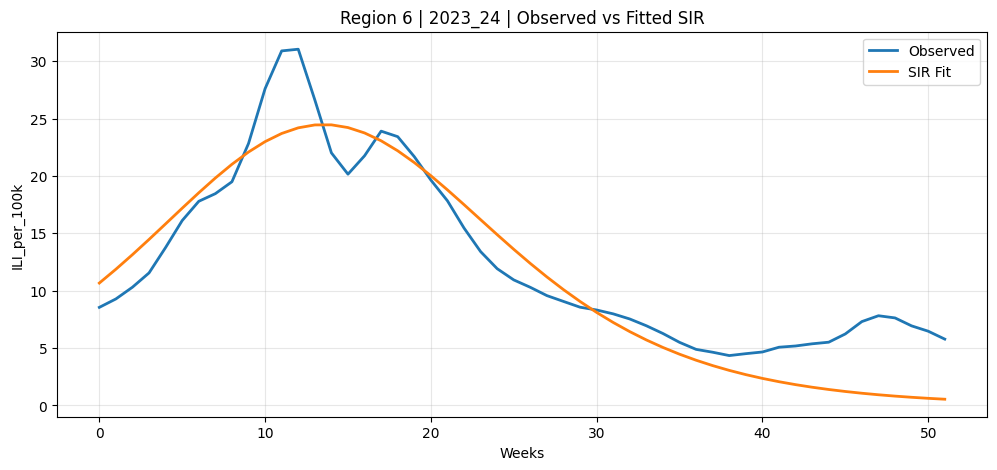

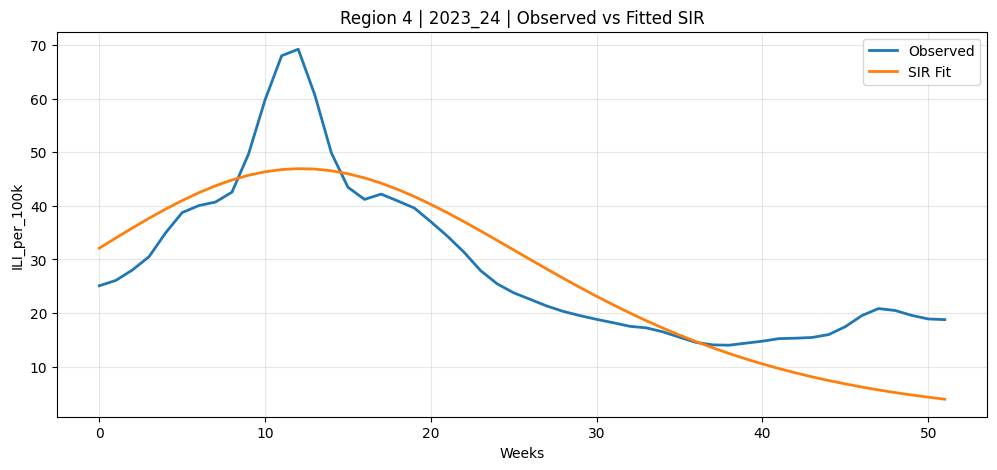

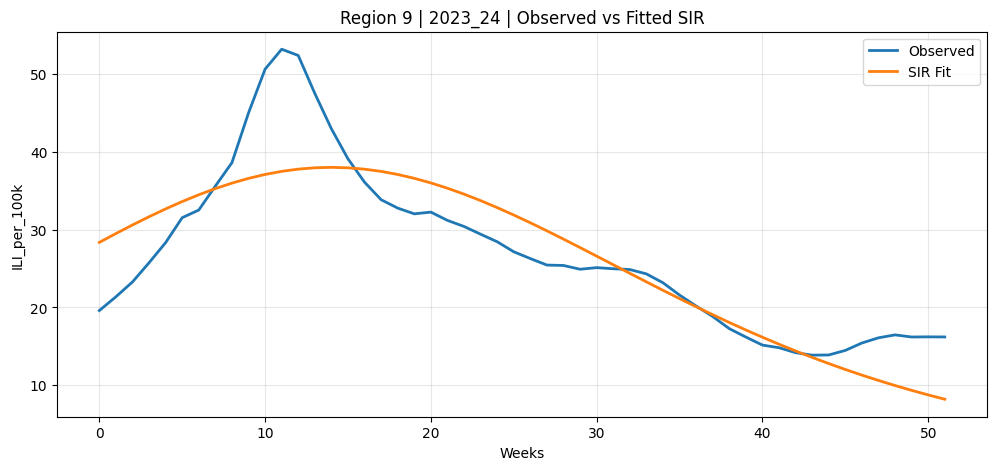

In [ ]:
plot_sir_fit(pred_df, "Region 6", "2023_24")

plot_sir_fit(pred_df, "Region 4", "2023_24")

plot_sir_fit(pred_df, "Region 9", "2023_24")

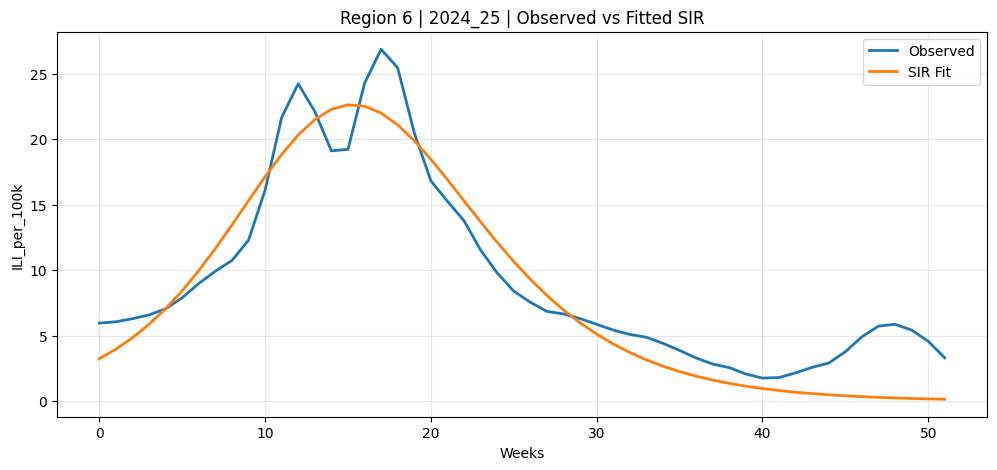

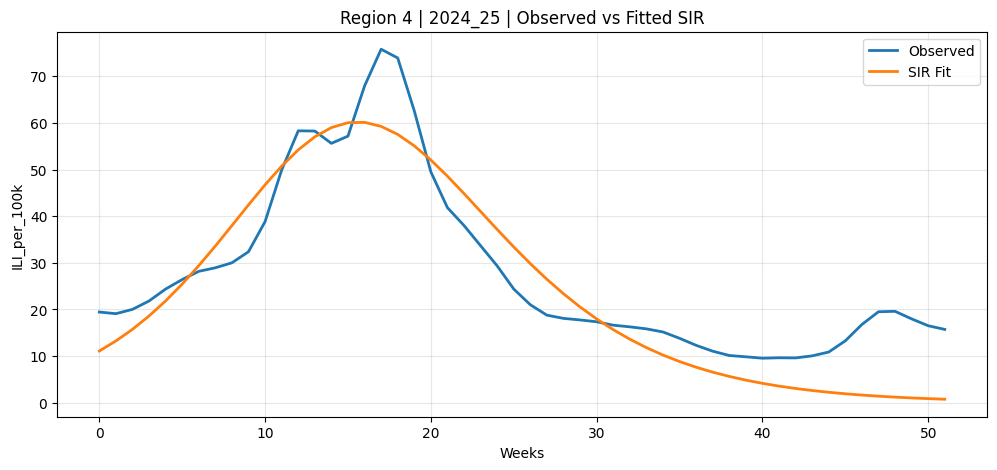

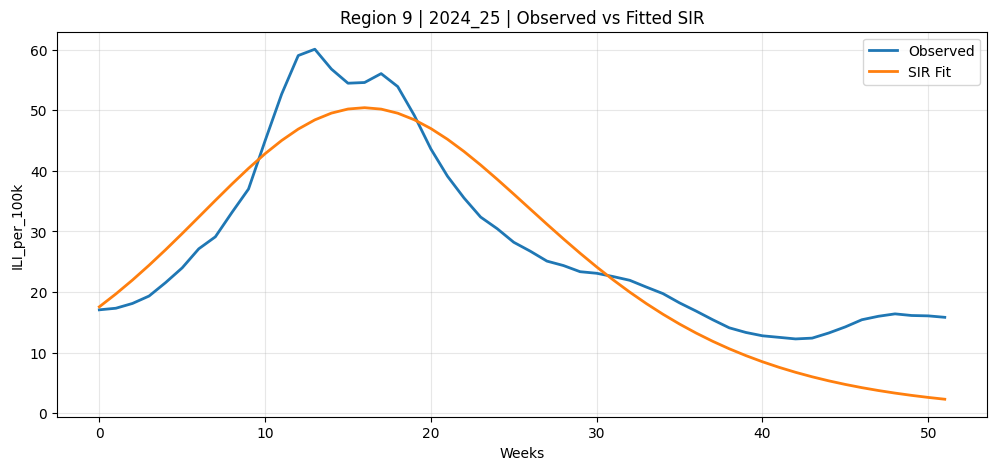

In [ ]:
plot_sir_fit(pred_df, "Region 6", "2024_25")

plot_sir_fit(pred_df, "Region 4", "2024_25")

plot_sir_fit(pred_df, "Region 9", "2024_25")

In [ ]:
# ==========================================================
# FUNCTION: Internal SIR Dynamics Plot
# Uses fitted parameters from results_df
# ==========================================================

def plot_sir_dynamics(results_df, pred_df, region_name, season_name, N=100000):

    row = results_df[
        (results_df["Region"] == region_name) &
        (results_df["Season"] == season_name)
    ].copy()

    if row.empty:
        print("No fitted results found for selected Region / Season")
        return

    beta = row["beta"].values[0]
    gamma = row["gamma"].values[0]

    # if stored in results_df
    if "I0_frac" in results_df.columns:
        I0_frac = row["I0_frac"].values[0]
    else:
        I0_frac = 0.0005

    # number of weeks from pred_df
    sample = pred_df[
        (pred_df["Region"] == region_name) &
        (pred_df["Season"] == season_name)
    ]

    if sample.empty:
        print("No prediction data found.")
        return

    t = np.arange(len(sample))

    I0 = I0_frac * N
    R0 = 0
    S0 = N - I0

    y0 = [S0, I0, R0]

    sol = odeint(
        sir_model,
        y0,
        t,
        args=(beta, gamma, N)
    )

    S, I, R = sol.T

    plt.figure(figsize=(12,5))

    plt.plot(t, S, label="Susceptible", linewidth=2)
    plt.plot(t, I, label="Infected", linewidth=2)
    plt.plot(t, R, label="Recovered", linewidth=2)

    plt.title(f"SIR Dynamics | {region_name} | {season_name}")
    plt.xlabel("Weeks")
    plt.ylabel("Population")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

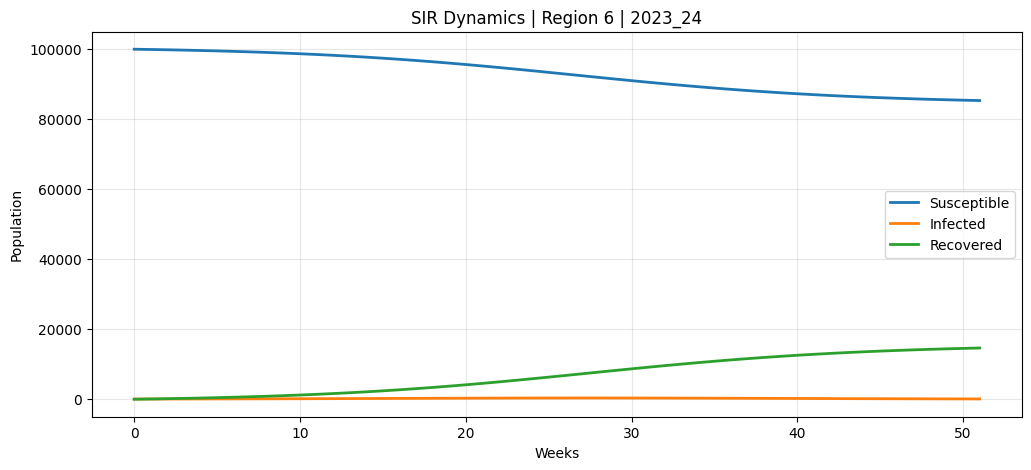

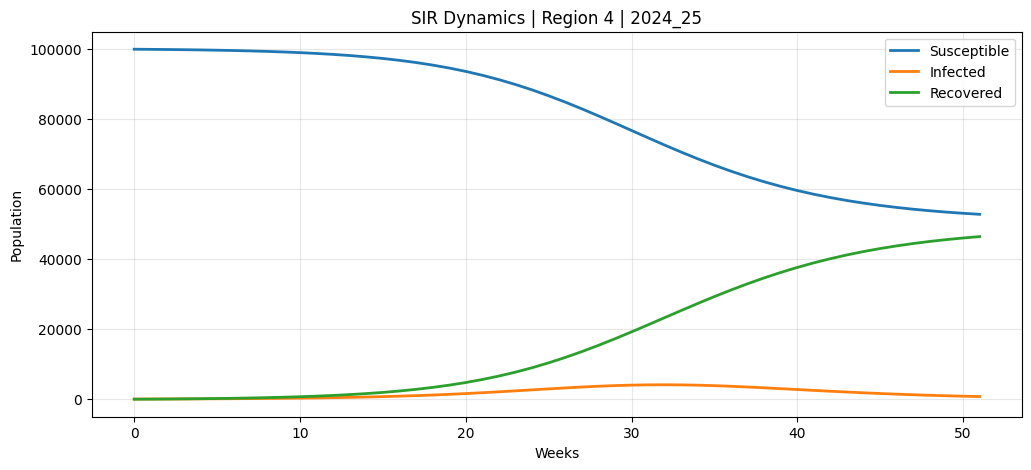

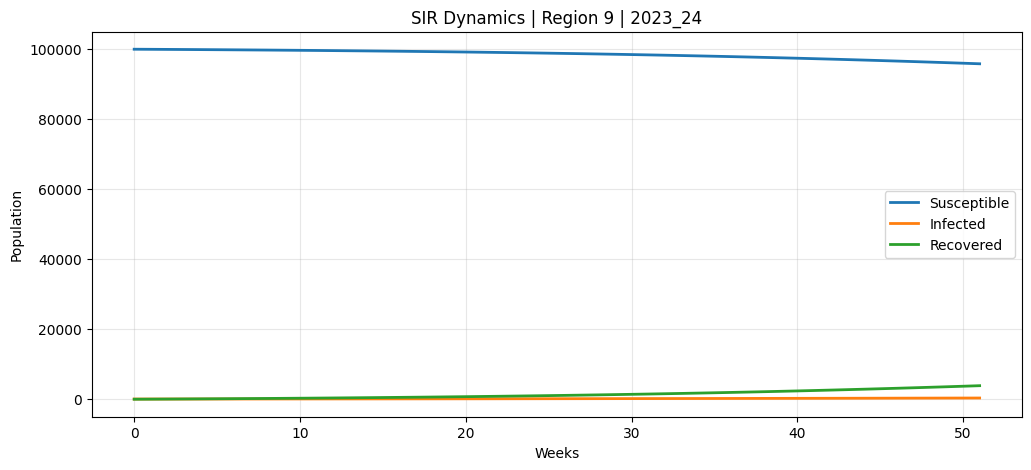

In [ ]:
plot_sir_dynamics(results_df, pred_df, "Region 6", "2023_24")

plot_sir_dynamics(results_df, pred_df, "Region 4", "2024_25")

plot_sir_dynamics(results_df, pred_df, "Region 9", "2023_24")

#Seasonal SEIR Model

In [ ]:
selected_seasons = ["2023_24", "2024_25"]
selected_regions = ["Region 4", "Region 6", "Region 9"]

target_col = "ILI_per_100k"
N = 100000

In [ ]:
def prepare_season_data(df, region_name, season_name, target_col):

    temp = df[
        (df["Region"] == region_name) &
        (df["Season"] == season_name)
    ].copy()

    if len(temp) == 0:
        return None

    temp["Season_Order"] = np.where(
        temp["Week"] >= 40,
        temp["Week"] - 40,
        temp["Week"] + 13
    )

    temp = temp.sort_values("Season_Order").reset_index(drop=True)

    temp["Smoothed"] = (
        temp[target_col]
        .rolling(3, center=True)
        .mean()
    )

    temp["Smoothed"] = temp["Smoothed"].fillna(temp[target_col])

    return temp

In [ ]:
def seir_model(y, t, beta0, beta1, phi, sigma, gamma, N):

    S, E, I, R = y

    beta_t = beta0 * (
        1 + beta1 * np.cos((2 * np.pi * t / 52) + phi)
    )

    dSdt = -beta_t * S * I / N
    dEdt = beta_t * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return [dSdt, dEdt, dIdt, dRdt]

In [ ]:
def simulate_seir(params, observed, N):

    beta0, beta1, phi, sigma, gamma, E0f, I0f, rho = params

    E0 = E0f * N
    I0 = I0f * N
    R0 = 0
    S0 = N - E0 - I0

    y0 = [S0, E0, I0, R0]

    t = np.arange(len(observed))

    sol = odeint(
        seir_model,
        y0,
        t,
        args=(beta0, beta1, phi, sigma, gamma, N)
    )

    S, E, I, R = sol.T

    predicted_obs = rho * I

    return predicted_obs, S, E, I, R

In [ ]:
def objective_seir(params, observed, N):

    predicted_obs, _, _, _, _ = simulate_seir(
        params, observed, N
    )

    mse = np.mean((observed - predicted_obs) ** 2)

    return mse

In [ ]:
def fit_one_seir(region_name, season_name):

    temp = prepare_season_data(
        df, region_name, season_name, target_col
    )

    if temp is None:
        return None

    observed = temp["Smoothed"].values

    initial_guess = [
        0.8,      # beta0
        0.25,     # beta1
        0.0,      # phi
        0.6,      # sigma
        0.35,     # gamma
        0.0005,   # E0f
        0.0005,   # I0f
        0.01      # rho
    ]

    bounds = [
        (0.01, 3.0),          # beta0
        (0.0, 1.0),           # beta1
        (-np.pi, np.pi),      # phi
        (0.05, 2.0),          # sigma
        (0.05, 1.5),          # gamma
        (1e-7, 0.01),         # E0f
        (1e-7, 0.01),         # I0f
        (1e-6, 1.0)           # rho
    ]

    result = minimize(
        objective_seir,
        initial_guess,
        args=(observed, N),
        method="L-BFGS-B",
        bounds=bounds
    )

    params = result.x

    fitted, S, E, I, R = simulate_seir(
        params, observed, N
    )

    rmse = np.sqrt(np.mean((observed - fitted)**2))
    mae = np.mean(np.abs(observed - fitted))

    peak_obs = np.argmax(observed)
    peak_fit = np.argmax(fitted)

    peak_error = abs(peak_obs - peak_fit)

    beta0, beta1, phi, sigma, gamma, E0f, I0f, rho = params

    R0_est = beta0 / gamma

    summary = {
        "Region": region_name,
        "Season": season_name,
        "beta0": beta0,
        "beta1": beta1,
        "phi": phi,
        "sigma": sigma,
        "gamma": gamma,
        "R0": R0_est,
        "RMSE": rmse,
        "MAE": mae,
        "Peak_Error": peak_error
    }

    pred = pd.DataFrame({
        "Region": region_name,
        "Season": season_name,
        "Week_Index": np.arange(len(observed)),
        "Observed": observed,
        "Fitted": fitted
    })

    return summary, pred

In [ ]:
all_results = []
all_preds = []

for region in selected_regions:
    for season in selected_seasons:

        out = fit_one_seir(region, season)

        if out is not None:
            summary, pred = out
            all_results.append(summary)
            all_preds.append(pred)

In [ ]:
results_df = pd.DataFrame(all_results)
pred_df = pd.concat(all_preds, ignore_index=True)

results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df.round(4)

,Region,Season,beta0,beta1,phi,sigma,gamma,R0,RMSE,MAE,Peak_Error
0,Region 6,2023_24,0.0100,0.0350,3.1415,0.0955,0.1047,0.0955,3.1427,2.6879,2
1,Region 9,2023_24,0.0265,0.0000,3.1407,0.0500,0.1484,0.1783,3.9428,3.0421,1
2,Region 4,2024_25,0.8954,0.3493,0.4271,0.7332,0.5687,1.5746,5.6557,4.1793,2
3,Region 6,2024_25,0.0248,1.0000,3.1416,0.0500,1.4953,0.0166,6.8081,4.8521,15
4,Region 9,2024_25,0.0100,0.0000,-3.1416,0.0807,0.0906,0.1104,7.0396,5.9606,1
5,Region 4,2023_24,0.0100,0.0000,3.1416,0.1564,0.0631,0.1584,7.0685,5.5527,3


In [ ]:
def plot_seir_fit(region_name, season_name):

    temp = pred_df[
        (pred_df["Region"] == region_name) &
        (pred_df["Season"] == season_name)
    ]

    plt.figure(figsize=(12,5))

    plt.plot(
        temp["Observed"].values,
        label="Observed",
        linewidth=2
    )

    plt.plot(
        temp["Fitted"].values,
        label="Seasonal SEIR Fit",
        linewidth=2
    )

    plt.title(f"{region_name} | {season_name} | Seasonal SEIR")
    plt.xlabel("Weeks")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

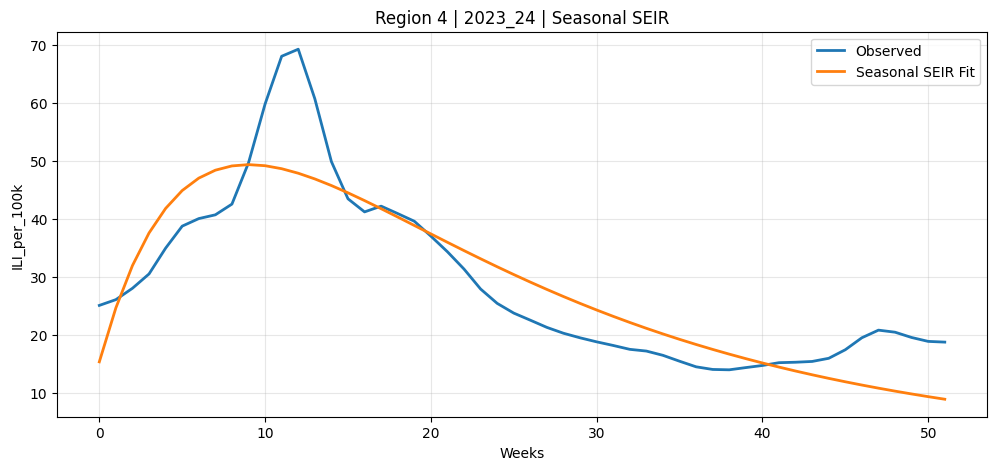

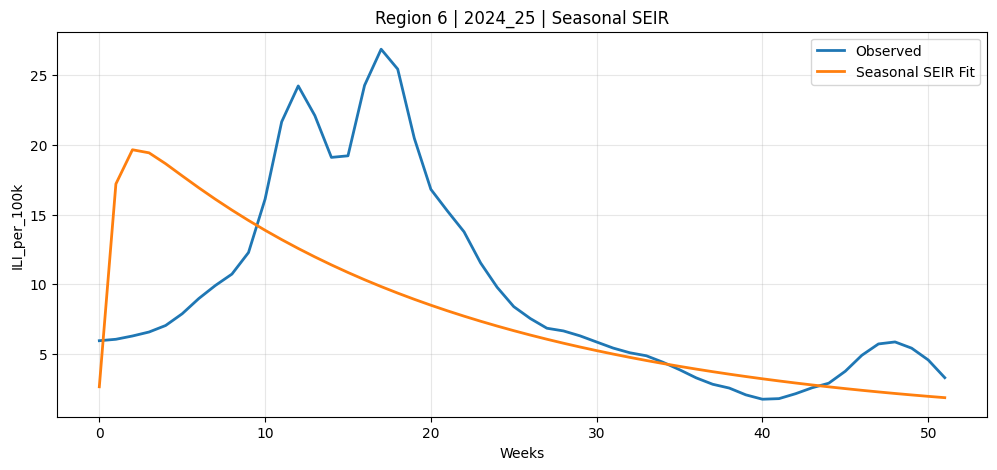

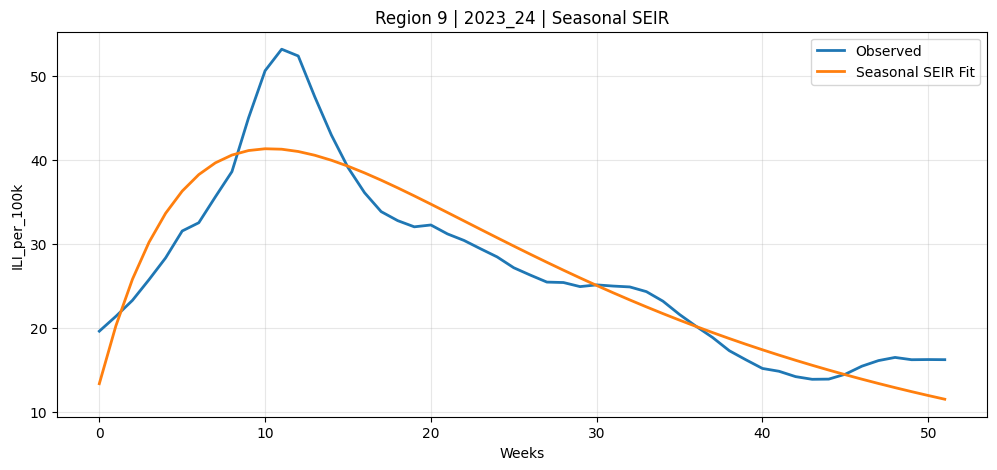

In [ ]:
plot_seir_fit("Region 4", "2023_24")
plot_seir_fit("Region 6", "2024_25")
plot_seir_fit("Region 9", "2023_24")

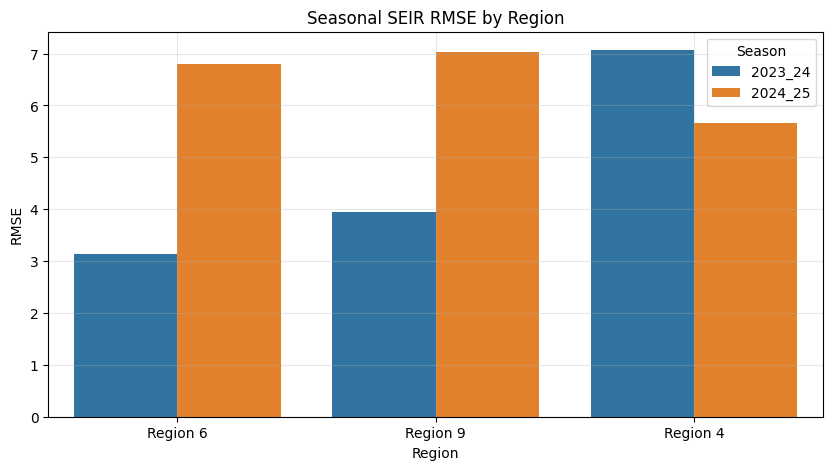

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Region",
    y="RMSE",
    hue="Season"
)

plt.title("Seasonal SEIR RMSE by Region")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.optimize import minimize

In [ ]:
df = pd.read_csv("/content/master_influenza_dataset.csv")

In [ ]:
selected_regions = ["Region 4", "Region 6", "Region 9"]
selected_seasons = ["2023_24", "2024_25"]

target_col = "ILI_per_100k"
N = 100000

sigma_fixed = 1.0
gamma_fixed = 0.6

In [ ]:
def prepare_data(df, region_name, season_name):

    temp = df[
        (df["Region"] == region_name) &
        (df["Season"] == season_name)
    ].copy()

    if len(temp) == 0:
        return None

    temp["Season_Order"] = np.where(
        temp["Week"] >= 40,
        temp["Week"] - 40,
        temp["Week"] + 13
    )

    temp = temp.sort_values("Season_Order").reset_index(drop=True)

    temp["Smoothed"] = (
        temp[target_col]
        .rolling(3, center=True)
        .mean()
    )

    temp["Smoothed"] = temp["Smoothed"].fillna(temp[target_col])

    return temp

In [ ]:
def seir_model(y, t, beta, sigma, gamma, N):

    S, E, I, R = y

    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return [dSdt, dEdt, dIdt, dRdt]

In [ ]:
def simulate_seir(params, observed, N):

    beta, E0f, I0f, rho = params

    E0 = E0f * N
    I0 = I0f * N
    R0 = 0
    S0 = N - E0 - I0

    y0 = [S0, E0, I0, R0]

    t = np.arange(len(observed))

    sol = odeint(
        seir_model,
        y0,
        t,
        args=(beta, sigma_fixed, gamma_fixed, N)
    )

    S, E, I, R = sol.T

    predicted = rho * I

    return predicted, S, E, I, R

In [ ]:
def objective(params, observed, N):

    predicted, _, _, _, _ = simulate_seir(
        params, observed, N
    )

    mse = np.mean((observed - predicted)**2)

    return mse

In [ ]:
def fit_one_case(region_name, season_name):

    temp = prepare_data(df, region_name, season_name)

    if temp is None:
        return None

    observed = temp["Smoothed"].values

    initial_guess = [
        0.8,        # beta
        0.0005,     # E0f
        0.0005,     # I0f
        0.01        # rho
    ]

    bounds = [
        (0.01, 3.0),
        (1e-7, 0.01),
        (1e-7, 0.01),
        (1e-6, 1.0)
    ]

    result = minimize(
        objective,
        initial_guess,
        args=(observed, N),
        method="L-BFGS-B",
        bounds=bounds
    )

    best = result.x

    fitted, S, E, I, R = simulate_seir(
        best, observed, N
    )

    beta, E0f, I0f, rho = best

    rmse = np.sqrt(np.mean((observed - fitted)**2))
    mae = np.mean(np.abs(observed - fitted))

    peak_obs = np.argmax(observed)
    peak_fit = np.argmax(fitted)

    peak_error = abs(peak_obs - peak_fit)

    R0_est = beta / gamma_fixed

    summary = {
        "Region": region_name,
        "Season": season_name,
        "beta": beta,
        "sigma": sigma_fixed,
        "gamma": gamma_fixed,
        "R0": R0_est,
        "RMSE": rmse,
        "MAE": mae,
        "Peak_Error": peak_error
    }

    pred = pd.DataFrame({
        "Region": region_name,
        "Season": season_name,
        "Week_Index": np.arange(len(observed)),
        "Observed": observed,
        "Fitted": fitted
    })

    return summary, pred

In [ ]:
all_results = []
all_preds = []

for region in selected_regions:
    for season in selected_seasons:

        out = fit_one_case(region, season)

        if out is not None:
            summary, pred = out
            all_results.append(summary)
            all_preds.append(pred)

In [ ]:
results_df = pd.DataFrame(all_results)
pred_df = pd.concat(all_preds, ignore_index=True)

results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df.round(4)

,Region,Season,beta,sigma,gamma,R0,RMSE,MAE,Peak_Error
0,Region 6,2024_25,0.9625,1.0,0.6,1.6042,2.5660,2.1542,2
1,Region 6,2023_24,0.8279,1.0,0.6,1.3798,3.6937,2.9007,3
2,Region 9,2023_24,0.6562,1.0,0.6,1.0936,5.3288,3.9634,2
3,Region 9,2024_25,0.7871,1.0,0.6,1.3118,7.0638,6.1142,3
4,Region 4,2023_24,0.6786,1.0,0.6,1.1309,8.4989,6.6266,1
5,Region 4,2024_25,0.9149,1.0,0.6,1.5248,8.5578,7.1336,1


In [ ]:
def plot_fit(region_name, season_name):

    temp = pred_df[
        (pred_df["Region"] == region_name) &
        (pred_df["Season"] == season_name)
    ]

    plt.figure(figsize=(12,5))

    plt.plot(
        temp["Observed"].values,
        label="Observed",
        linewidth=2
    )

    plt.plot(
        temp["Fitted"].values,
        label="Constrained SEIR",
        linewidth=2
    )

    plt.title(f"{region_name} | {season_name} | Constrained SEIR")
    plt.xlabel("Weeks")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

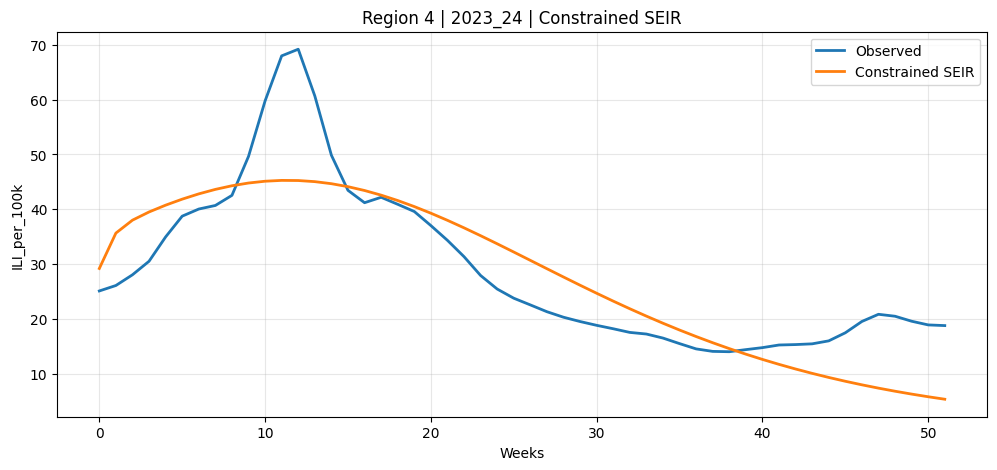

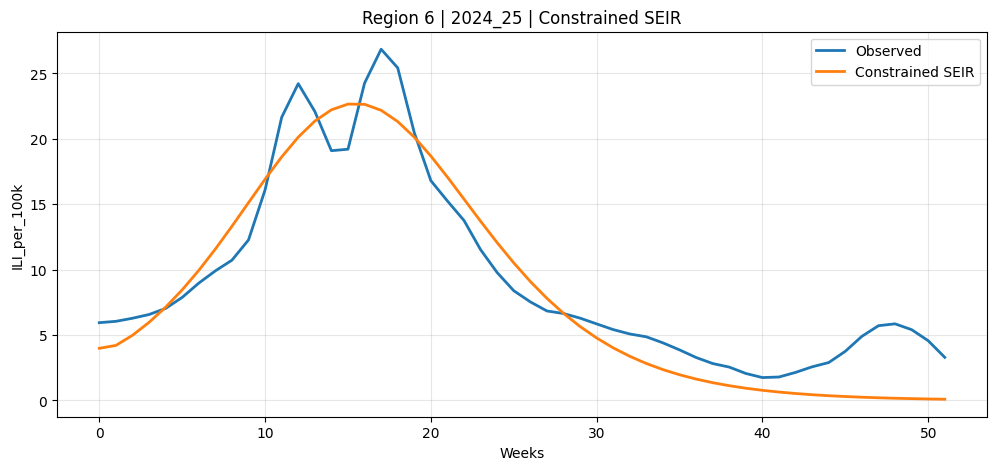

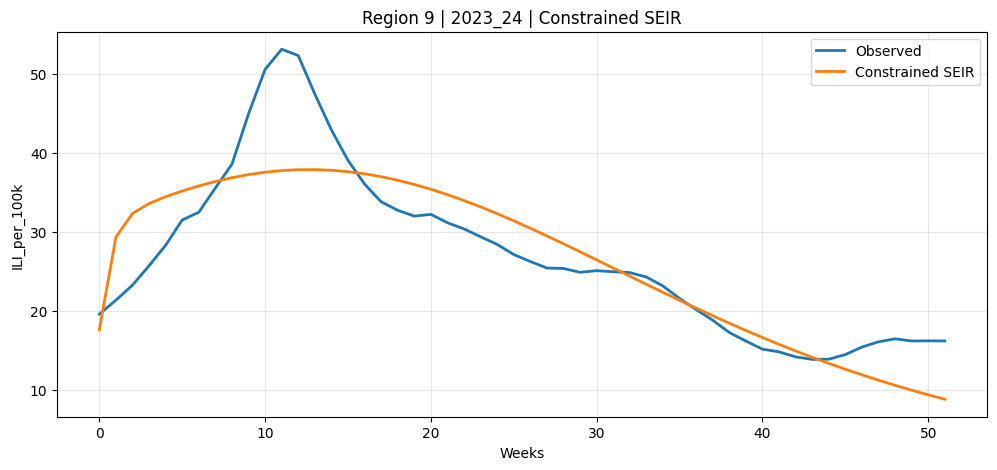

In [ ]:
plot_fit("Region 4", "2023_24")
plot_fit("Region 6", "2024_25")
plot_fit("Region 9", "2023_24")